## Experiment der Beschreibung von Hochwasser mit ML Methoden

Skizze: 

Hochwasserereignis am Rhein mit ML Methoden untersuchen (zuerst mit Random Forest):

Open-Source verfügbare Prädiktoren, welche auf ihre Relevanz getestet und mittels Feature Engineering verknüpft werden können:

Niederschläge, ET_p, ET_a, Lufttemperatur (DWD)
Hydrochemische Parameter des Rheins (Gütemessstellen: Sauerstoffgehalt, elek. Leitfähigkeit, Durchflusswerte, pH-Werte, Wassertemperatur)
Lagged Features: zb Niederschlag - 7 Tage
Bodenfeuchte?
ggfs. ergänzend Fernerkundungsdaten einbauen zb Sentinel-1 und Sentinel-2 (Grün, Rot, NDCI, NDVI, NDWI, SWIR)
Feature Importance prüfen, cross validation, SHAP values Analyse

Für den Ansatz testen wir als Prädiktoren Niederschläge (Station Sinzig) mit t, t-1, t-3 und t-7 sowie Pegeldaten des Pegels in Bonn mit t, t-1, t-3 und t-7.

In [191]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [141]:
df_pegel = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Pegeldaten_Bonn.csv", delimiter=";", header=0)

In [142]:
df_pegel

,Datum,t,t_minus1,t_minus_3,t_minus7
0,15.09.2009,162.489583,159.552083,172.041667,203.864583
1,16.09.2009,164.364583,162.489583,164.781250,196.010417
2,17.09.2009,159.812500,164.364583,159.552083,185.343750
3,18.09.2009,155.489583,159.812500,162.489583,178.000000
4,19.09.2009,147.791667,155.489583,164.364583,172.041667
...,...,...,...,...,...
6024,14.03.2026,282.416667,277.895833,280.552083,329.843750
6025,15.03.2026,314.239583,282.416667,276.989583,317.000000
6026,16.03.2026,317.864583,314.239583,277.895833,305.468750
6027,17.03.2026,311.125000,317.864583,282.416667,293.333333


In [143]:
df_pegel ["Datum"]

0       15.09.2009
1       16.09.2009
2       17.09.2009
3       18.09.2009
4       19.09.2009
           ...    
6024    14.03.2026
6025    15.03.2026
6026    16.03.2026
6027    17.03.2026
6028    18.03.2026
Name: Datum, Length: 6029, dtype: object

In [144]:
# die zeile ist auch wichtig fürs rf modell später 
df_pegel["Datum"] = pd.to_datetime(df_pegel["Datum"], format="%d.%m.%Y")

In [146]:
# Pegeldaten herrichten, fehlende Tage mitteln


df_pegel = df_pegel.sort_values("Datum")
full_range = pd.date_range(start="2009-09-08", end="2026-03-18", freq="D")


df_pegel = df_pegel.set_index("Datum").reindex(full_range)


df_pegel["t"] = df_pegel["t"].interpolate(method="linear")


df_pegel = df_pegel.reset_index().rename(columns={"index": "Datum"})
df_pegel["Datum"] = df_pegel["Datum"].dt.strftime("%d.%m.%Y")

df_pegel.to_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Pegeldaten_Bonn_filled.csv", index=False, header=False)

print("Fertig!")

Fertig!


Wie viele Tage gab es in unserem Datensatz? 

In [23]:
start = pd.to_datetime("08.09.2009", format="%d.%m.%Y")
end   = pd.to_datetime("18.03.2026", format="%d.%m.%Y")

days = (end - start).days + 1  
print(days)

6036


Für die Niederschläge fehlen anscheinend Daten. Diese auch noch interpolieren und auffüllen.

In [147]:
df_niederschlag = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Niederschlag_Sinzig.csv", delimiter=";", header=0)

In [149]:
df_niederschlag["Datum"]

0       15.09.2009
1       16.09.2009
2       17.09.2009
3       18.09.2009
4       19.09.2009
           ...    
6024    14.03.2026
6025    15.03.2026
6026    16.03.2026
6027    17.03.2026
6028    18.03.2026
Name: Datum, Length: 6029, dtype: object

In [150]:
# die zeile ist auch wichtig fürs rf modell später 
df_niederschlag["Datum"] = pd.to_datetime(df_niederschlag["Datum"], format="%d.%m.%Y")

In [39]:
# Niederschlagsdaten herrichten, fehlende Tage mitteln




df_niederschlag = df_niederschlag.sort_values("Datum")
full_range = pd.date_range(start="2009-09-08", end="2026-03-18", freq="D")


df_niederschlag = df_niederschlag.set_index("Datum").reindex(full_range)


df_niederschlag["Wert"] = df_niederschlag["Wert"].interpolate(method="linear")


df_niederschlag = df_niederschlag.reset_index().rename(columns={"index": "Datum"})
df_niederschlag["Datum"] = df_niederschlag["Datum"].dt.strftime("%d.%m.%Y")

df_niederschlag.to_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Niederschlag_Bonn_filled.csv", index=False, header=False)

print("Fertig!")

Fertig!


Jetzt kann das erste Modell mit den Parametern p-1, p-3, p-7, t, t-1, t-3, t-7 und dem Testparameter p trainiert werden!

In [151]:
df_pegel["Datum"] = pd.to_datetime(df_pegel["Datum"], format="%d.%m.%Y")
df_niederschlag["Datum"] = pd.to_datetime(df_niederschlag["Datum"], format="%d.%m.%Y")

df_niederpegel = pd.merge(df_pegel, df_niederschlag, on="Datum")


df_niederpegel = df_niederpegel.sort_values("Datum") # nach datum sortieren

In [152]:
df_niederpegel
#df_niederpegel["p_minus3"]

,Datum,t,t_minus1,t_minus_3,t_minus7,p,p_minus1,p_minus3,p_minus7
0,2009-09-15,162.489583,159.552083,172.041667,203.864583,0.1,11.6,0.0,0.0
1,2009-09-16,164.364583,162.489583,164.781250,196.010417,0.0,0.1,1.1,0.0
2,2009-09-17,159.812500,164.364583,159.552083,185.343750,0.0,0.0,11.6,0.0
3,2009-09-18,155.489583,159.812500,162.489583,178.000000,0.0,0.0,0.1,0.0
4,2009-09-19,147.791667,155.489583,164.364583,172.041667,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
6024,2026-03-14,282.416667,277.895833,280.552083,329.843750,2.3,16.1,1.9,0.0
6025,2026-03-15,314.239583,282.416667,276.989583,317.000000,0.6,2.3,0.0,0.0
6026,2026-03-16,317.864583,314.239583,277.895833,305.468750,0.6,0.6,16.1,0.0
6027,2026-03-17,311.125000,317.864583,282.416667,293.333333,0.1,0.6,2.3,0.4


In [153]:
features = df_niederpegel[["p", "p_minus1", "p_minus3", "p_minus7", "t_minus1", "t_minus_3", "t_minus7"]]
target = df_niederpegel[["t"]]

In [154]:
df_niederpegel = df_niederpegel.dropna()

X = features
y = target

split_date = "2020-08-01"

X_train = X[df_niederpegel["Datum"] < split_date]
X_test  = X[df_niederpegel["Datum"] >= split_date]

y_train = y[df_niederpegel["Datum"] < split_date]
y_test  = y[df_niederpegel["Datum"] >= split_date]

In [183]:
# ERSTES MODELL

def rf_modell(dataframe):
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    print("RMSE:", rmse)
    print("R2:", r2)

    rfmodell_output_path= r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\RF Nur Niederschlag und Pegeldaten lagged"
    
    plt.figure(figsize=(12,5))
    plt.plot(dataframe["Datum"][dataframe["Datum"] >= split_date], y_test, label="Real")
    plt.plot(dataframe["Datum"][dataframe["Datum"] >= split_date], y_pred, label="Prediction")
    plt.legend()
    plt.title(f"Pegel-Vorhersage für Daten ab {split_date}")

    plt.text(0.02, 0.95, f"R² = {r2:.2f}", transform=plt.gca().transAxes, verticalalignment='top')
    plt.savefig(f"{rfmodell_output_path}\\Pegel-Vorhersage_für_Daten_ab_{split_date}.png", dpi=300, bbox_inches="tight")

    plt.show()

    # importances = model.feature_importances_

    # feat_imp = pd.Series(importances, index=features.columns).sort_values(ascending=False)

    # print(feat_imp)

    # feat_imp.plot(kind="bar", title="Feature Importance")

C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE: 19.576036482201047
R2: 0.9765987006783796


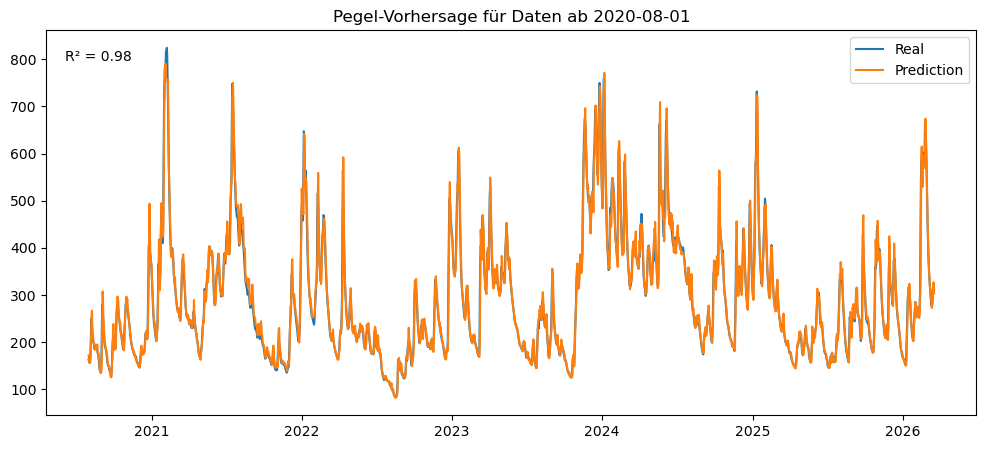

t_minus1     0.977128
t_minus_3    0.010166
p_minus1     0.003348
p_minus3     0.003193
t_minus7     0.002586
p            0.002070
p_minus7     0.001509
dtype: float64


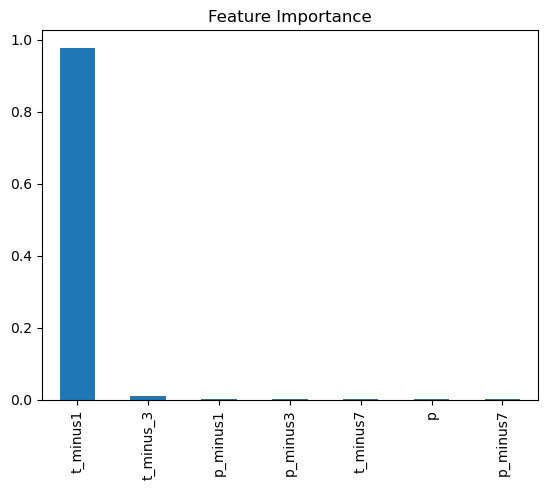

In [161]:
rf_modell(df_niederpegel)


Bevor es weitergeht, lasse ich die feature importance prüfen.

t_minus1 dominiert die feature importance, damit war zu rechnen. Anschließend kann ich dt testen, also t- t-1 als Differenz. ob das geeigneter für hochwasser ist.

## Ohne t-1, t-3, t-7

In [168]:
features = df_niederpegel[["p", "p_minus1", "p_minus3", "p_minus7", ]]
target = df_niederpegel[["t"]]

df_niederpegel = df_niederpegel.dropna()

X = features
y = target

split_date = "2020-08-01"

X_train = X[df_niederpegel["Datum"] < split_date]
X_test  = X[df_niederpegel["Datum"] >= split_date]

y_train = y[df_niederpegel["Datum"] < split_date]
y_test  = y[df_niederpegel["Datum"] >= split_date]

C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE: 130.38565815555896
R2: -0.03812604586297841


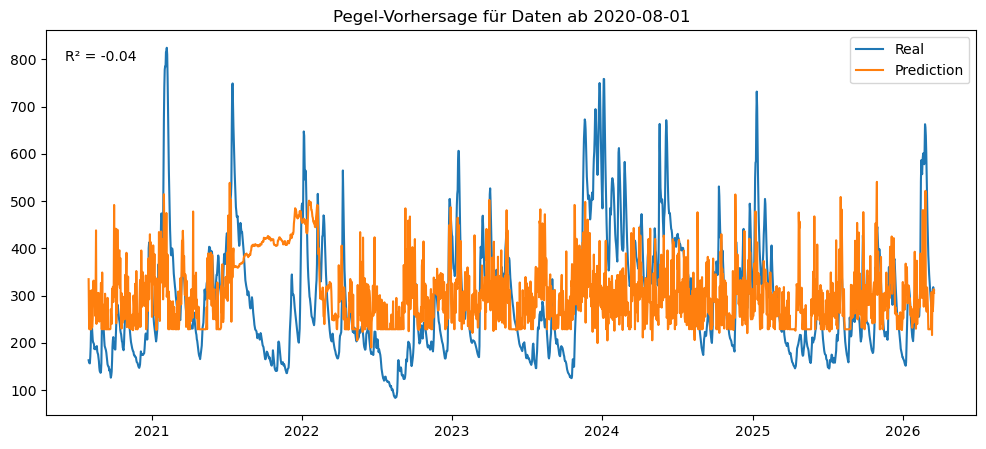

p_minus3    0.300794
p_minus7    0.293608
p_minus1    0.209282
p           0.196315
dtype: float64


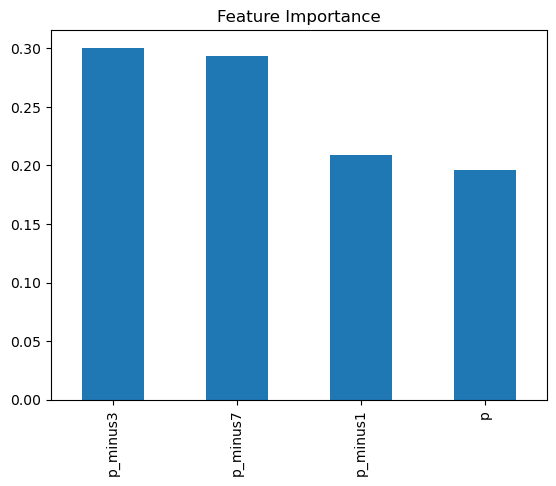

In [169]:
rf_modell(df_niederpegel)

ich teste jetzt mit mehr lagged variables, also p_minus14, 21, 30, gleiches für t.

In [94]:
df_pegel_lagged = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Pegeldaten_Bonn_mitmehrlagged.csv", delimiter=";", header=0)

In [95]:
df_pegel_lagged["Datum"] = pd.to_datetime(df_pegel_lagged["Datum"], format="%d.%m.%Y")

In [96]:
df_pegel_lagged

,Datum,t,t_minus1,t_minus_3,t_minus7,t_minus14,t_minus21,t_minus30
0,2009-10-08,125.385417,124.593750,110.302083,120.406250,139.468750,159.812500,203.864583
1,2009-10-09,120.145833,125.385417,117.635417,114.947917,137.250000,155.489583,196.010417
2,2009-10-10,121.812500,120.145833,124.593750,115.697917,132.302083,147.791667,185.343750
3,2009-10-11,139.927083,121.812500,125.385417,113.739583,129.562500,144.239583,178.000000
4,2009-10-12,156.385417,139.927083,120.145833,110.302083,125.156250,144.104167,172.041667
...,...,...,...,...,...,...,...,...
6001,2026-03-14,282.416667,277.895833,280.552083,329.843750,552.927083,595.260417,307.677083
6002,2026-03-15,314.239583,282.416667,276.989583,317.000000,502.343750,577.906250,425.177083
6003,2026-03-16,317.864583,314.239583,277.895833,305.468750,458.583333,609.416667,542.677083
6004,2026-03-17,311.125000,317.864583,282.416667,293.333333,417.760417,662.500000,586.510417


In [180]:
df_niederschlag_lagged = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Niederschlag_Sinzig_mitmehrlagged.csv", delimiter=";", header=0)

df_niederschlag_lagged["Datum"] = pd.to_datetime(df_niederschlag_lagged["Datum"], format="%d.%m.%Y")

In [181]:
df_niederpegel_lagged = pd.merge(df_pegel_lagged, df_niederschlag_lagged, on="Datum")


df_niederpegel_lagged = df_niederpegel_lagged.sort_values("Datum") # nach datum sortieren

In [182]:
df_niederpegel_lagged

,Datum,t,t_minus1,t_minus_3,t_minus7,t_minus14,t_minus21,t_minus30,p,p_minus1,p_minus3,p_minus7,p_minus14,p_minus21,p_minus30
0,2009-10-08,125.385417,124.593750,110.302083,120.406250,139.468750,159.812500,203.864583,0.0,4.6,6.6,0.1,0.1,0.0,0.0
1,2009-10-09,120.145833,125.385417,117.635417,114.947917,137.250000,155.489583,196.010417,8.7,0.0,1.9,0.0,0.0,0.0,0.0
2,2009-10-10,121.812500,120.145833,124.593750,115.697917,132.302083,147.791667,185.343750,3.3,8.7,4.6,0.0,0.0,0.0,0.0
3,2009-10-11,139.927083,121.812500,125.385417,113.739583,129.562500,144.239583,178.000000,3.0,3.3,0.0,1.3,0.0,0.0,0.0
4,2009-10-12,156.385417,139.927083,120.145833,110.302083,125.156250,144.104167,172.041667,1.1,3.0,8.7,6.6,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6001,2026-03-14,282.416667,277.895833,280.552083,329.843750,552.927083,595.260417,307.677083,2.3,16.1,1.9,0.0,0.0,8.7,4.2
6002,2026-03-15,314.239583,282.416667,276.989583,317.000000,502.343750,577.906250,425.177083,0.6,2.3,0.0,0.0,0.0,4.5,2.9
6003,2026-03-16,317.864583,314.239583,277.895833,305.468750,458.583333,609.416667,542.677083,0.6,0.6,16.1,0.0,0.0,2.5,0.0
6004,2026-03-17,311.125000,317.864583,282.416667,293.333333,417.760417,662.500000,586.510417,0.1,0.6,2.3,0.4,0.0,1.1,5.6


In [175]:
features_lagged = df_niederpegel_lagged[["p", "p_minus1", "p_minus3", "p_minus7", "t_minus1", "t_minus_3", "t_minus7", "p_minus14", "p_minus21", "p_minus30", "t_minus14", "t_minus21", "t_minus30"]]
target_lagged = df_niederpegel_lagged[["t"]]

In [176]:
df_niederpegel_lagged["Datum"]

0      2009-10-08
1      2009-10-09
2      2009-10-10
3      2009-10-11
4      2009-10-12
          ...    
6001   2026-03-14
6002   2026-03-15
6003   2026-03-16
6004   2026-03-17
6005   2026-03-18
Name: Datum, Length: 6006, dtype: datetime64[ns]

In [177]:
df_niederpegel_lagged = df_niederpegel_lagged.dropna()

X_lagged = features_lagged
y_lagged = target_lagged

In [185]:


split_date = "2020-08-01"

X_train = X_lagged[df_niederpegel_lagged["Datum"] < split_date]
X_test  = X_lagged[df_niederpegel_lagged["Datum"] >= split_date]

y_train =  y_lagged[df_niederpegel_lagged["Datum"] < split_date]
y_test  = y_lagged[df_niederpegel_lagged["Datum"] >= split_date]

C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE: 19.812281887415338
R2: 0.9760304744837159


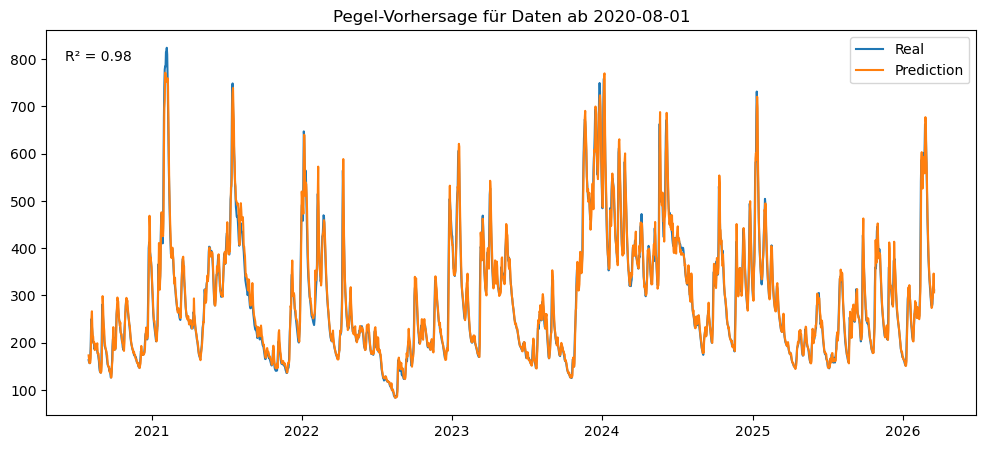

In [184]:
rf_modell(df_niederpegel_lagged)

Also bis jetzt absolutes Overfitting bei den Pegeldaten, wenn man t-1, t-3 oder sogar t-7 rausnimmt, wird die Korrelation deutlich schlechter. 

Ich schaue was xgboost aus meinen Daten macht.

## Test mit XGBoost

In [187]:
def xgb_modell(dataframe):

    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    print("RMSE:", rmse)
    print("R2:", r2)

    rfmodell_output_path= r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\RF Nur Niederschlag und Pegeldaten lagged"
    
    plt.figure(figsize=(12,5))
    plt.plot(dataframe["Datum"][dataframe["Datum"] >= split_date], y_test, label="Real")
    plt.plot(dataframe["Datum"][dataframe["Datum"] >= split_date], y_pred, label="Prediction")
    plt.legend()
    plt.title(f"Pegel-Vorhersage für Daten ab {split_date}")

    plt.text(0.02, 0.95, f"R² = {r2:.2f}", transform=plt.gca().transAxes, verticalalignment='top')
    plt.savefig(f"{rfmodell_output_path}\\XGBoost Pegel-Vorhersage_für_Daten_ab_{split_date}.png", dpi=300, bbox_inches="tight")

    plt.show()

    # importances = model.feature_importances_

    # feat_imp = pd.Series(importances, index=features.columns).sort_values(ascending=False)

    # print(feat_imp)

    # feat_imp.plot(kind="bar", title="Feature Importance")

C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE: 21.95703822415557
R2: 0.9705599898045906


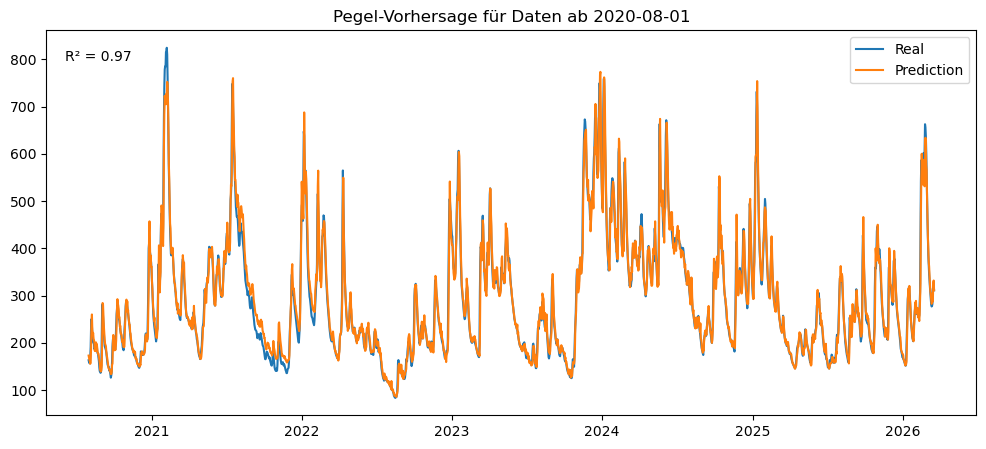

In [188]:
xgb_modell(df_niederpegel_lagged)

Da das Signal hier sehr einfach zu lernen ist mit t_minus1 etc (Pegel gestern ca. wie Pegel heute), ist die Modellwahl erstmal recht unbedeutend.

In [190]:
def lightgbm_modell(dataframe): 

    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    )

    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    print("RMSE:", rmse)
    print("R2:", r2)

    rfmodell_output_path= r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\RF Nur Niederschlag und Pegeldaten lagged"
    
    plt.figure(figsize=(12,5))
    plt.plot(dataframe["Datum"][dataframe["Datum"] >= split_date], y_test, label="Real")
    plt.plot(dataframe["Datum"][dataframe["Datum"] >= split_date], y_pred, label="Prediction")
    plt.legend()
    plt.title(f"Pegel-Vorhersage für Daten ab {split_date}")

    plt.text(0.02, 0.95, f"R² = {r2:.2f}", transform=plt.gca().transAxes, verticalalignment='top')
    plt.savefig(f"{rfmodell_output_path}\\LightGBM Pegel-Vorhersage_für_Daten_ab_{split_date}.png", dpi=300, bbox_inches="tight")

    plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3294
[LightGBM] [Info] Number of data points in the train set: 3950, number of used features: 13
[LightGBM] [Info] Start training from score 292.600723


C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE: 20.67185368172566
R2: 0.9739054816636565


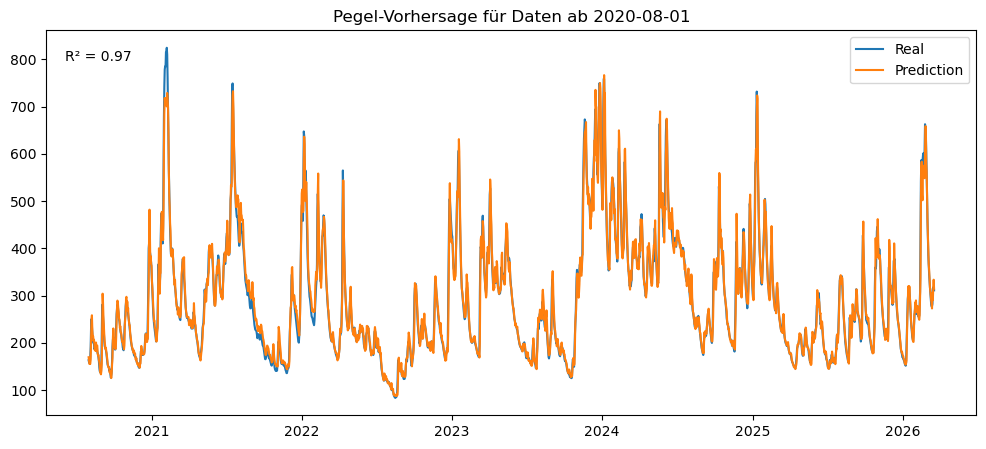

In [192]:
lightgbm_modell(df_niederpegel_lagged)

Wenn RF ca. wie XGBoost und LightGBM abliefert, ist mein Limit hier erstmal der Datensatz und nicht das Modell. Ich bleibe vorerst bei RF und arbeite weiter an meinen Features. Wäre Bodenfeuchte ein gedanke? Ich könnte auch mit rolling sums arbeiten.

Langfristig ist lightgbm vielleicht der beste allrounder, aber noch lohnt das nicht wirklich. Bei RF sollte ich auch mittelfristig mal mit SHAP values arbeiten, wenn ich interessantere features habe.